# PPTMixer: Detecting Genuine Multipartite Entanglement

Python implementation based on:
- B. Jungnitsch, T. Moroder and O. Gühne, Phys. Rev. Lett. 106, 190502 (2011)
- arXiv:1010.6049

This notebook demonstrates how to detect genuine multipartite entanglement using semidefinite programming.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pptmixer import (partial_transpose, fdecwit, fpptwit, entmon,
                       ghz_state, w_state, bell_state, 
                       dicke_state, add_white_noise)

np.set_printoptions(precision=4, suppress=True)

## 1. Partial Transpose Basics

First, let's understand the partial transpose operation.

In [2]:
rho_bell = bell_state('phi+')
print("Bell state:")
print(rho_bell)

# Partial transpose with respect to first qubit
rho_pt = partial_transpose(rho_bell, [0, 1], [2, 2])
print("Partial transpose:")
print(rho_pt)

# Check eigenvalues
eigenvalues = np.linalg.eigvalsh(rho_pt)
print(f"Eigenvalues: {eigenvalues}")
print(f"Minimum eigenvalue: {min(eigenvalues):.4f}")
print("Negative eigenvalue indicates entanglement (PPT criterion)")

Bell state:
[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]
Partial transpose:
[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]
Eigenvalues: [-0.5  0.5  0.5  0.5]
Minimum eigenvalue: -0.5000
Negative eigenvalue indicates entanglement (PPT criterion)


## 2. Two-Qubit Entanglement Detection

For two qubits, there's only one bipartition, so the test is equivalent to the PPT criterion.

In [3]:
# Test Bell state
print("Testing Bell state:")
min_val, W = fdecwit(rho_bell)
print(f"  Minimum value: {min_val:.3f}")
if min_val < 0:
    print("Entangled!")
    print(f"\nWitness W:")
    print(W)

Testing Bell state:
  Minimum value: -0.500
Entangled!

Witness W:
[[ 0. +0.j  0. +0.j  0. +0.j -0.5+0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [-0.5+0.j  0. +0.j  0. +0.j  0. +0.j]]


In [4]:
W_analytic = 0.5 * np.eye(4) - rho_bell
print("Analytic witness:")
print(W_analytic)
print(rf"\nTr(W\rho) = {np.trace(W_analytic @ rho_bell).real:.3f}")

Analytic witness:
[[ 0. +0.j  0. +0.j  0. +0.j -0.5+0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [-0.5+0.j  0. +0.j  0. +0.j  0. +0.j]]
\nTr(W\rho) = -0.500


## 3. Three-Qubit GHZ State

Now we test genuine multipartite entanglement in a 3-qubit system.

In [5]:
# Create 3-qubit GHZ state
rho_ghz3 = ghz_state(3)
print(rho_ghz3)

# Test with fully PPT witness
print("Testing with fdecwit:")
min_val, W = fdecwit(rho_ghz3)
print(f"Minimum value: {min_val:.6f}")
if min_val < 0:
    print("Genuinely multipartite entangled!")

[[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]
Testing with fdecwit:
Minimum value: -0.166667
Genuinely multipartite entangled!


## 4. Three-Qubit W State

In [6]:
# Create 3-qubit W state
rho_w3 = w_state(3)
print(rho_w3)

min_val, W = fdecwit(rho_w3)
print(f"\nMinimum value: {min_val:.6f}")
if min_val < 0:
    print("Genuinely multipartite entangled!")

[[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j 0.3333+0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j 0.3333+0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.3333+0.j 0.    +0.j 0.3333+0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j]]

Minimum value: -0.135966
Genuinely multipartite entangled!


## 5. White Noise Tolerance

Let's find how much white noise can be added while still detecting entanglement.

In [7]:
def find_noise_tolerance(rho, name="State", num_points=20):
    """Find the white noise tolerance for a state."""
    noise_levels = np.linspace(0, 1, num_points)
    min_vals = []
    
    for p in noise_levels:
        rho_noisy = add_white_noise(rho, p)
        min_val, _ = fdecwit(rho_noisy)
        min_vals.append(min_val)
    
    # Find threshold
    p_tol = None
    for i, (p, mv) in enumerate(zip(noise_levels, min_vals)):
        if mv >= 0:
            if i > 0:
                # Linear interpolation
                p_tol = noise_levels[i-1] + (0 - min_vals[i-1]) * (p - noise_levels[i-1]) / (mv - min_vals[i-1])
            else:
                p_tol = 0
            break
    
    if p_tol is None:
        p_tol = 1.0
    
    return noise_levels, min_vals, p_tol

In [8]:
# Test GHZ and W states
print("Computing noise tolerance")

noise_ghz, vals_ghz, ptol_ghz = find_noise_tolerance(ghz_state(3), "GHZ3", 15)
print(f"GHZ3 noise tolerance: p_tol = {ptol_ghz:.3f}")

noise_w, vals_w, ptol_w = find_noise_tolerance(w_state(3), "W3", 15)
print(f"W3 noise tolerance: p_tol = {ptol_w:.3f}")

Computing noise tolerance
GHZ3 noise tolerance: p_tol = 0.571
W3 noise tolerance: p_tol = 0.521


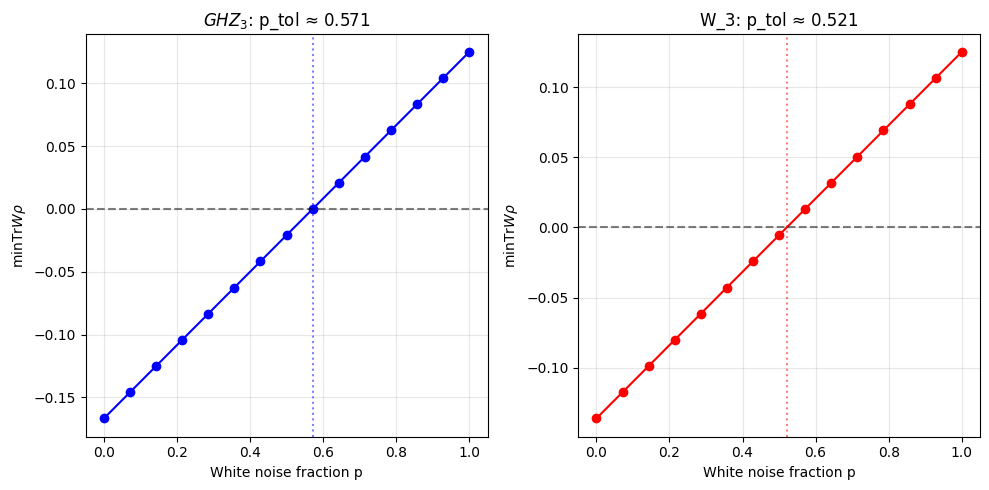

In [9]:
# Plot results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(noise_ghz, vals_ghz, 'b-o', label='GHZ₃')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=ptol_ghz, color='b', linestyle=':', alpha=0.5)
plt.xlabel('White noise fraction p')
plt.ylabel(r'$\min \text{Tr}W\rho$')
plt.title(rf'$GHZ_{3}$: p_tol ≈ {ptol_ghz:.3f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(noise_w, vals_w, 'r-o', label='W₃')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=ptol_w, color='r', linestyle=':', alpha=0.5)
plt.xlabel('White noise fraction p')
plt.ylabel(r'$\min \text{Tr}W\rho$')
plt.title(rf'W_3: p_tol ≈ {ptol_w:.3f}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Entanglement Monotone

The entanglement monotone quantifies how much genuine multipartite entanglement is present.

In [10]:
# Compare entanglement monotone for different states
print("Entanglement monotone:")
print(f"GHZ3: {entmon(ghz_state(3)):.4f}")
print(f"W3  : {entmon(w_state(3)):.4f}")

Entanglement monotone:
GHZ3: 0.5000
W3  : 0.4428


## 7. Four-Qubit Dicke State

The Dicke state |D_{2,4}> has 2 excitations among 4 qubits.

In [11]:
# Create Dicke state
rho_dicke = dicke_state(4, 2)
print(rho_dicke)

# This takes longer due to more bipartitions
min_val, W = fdecwit(rho_dicke)
print(f"Minimum value: {min_val:.3f}")
if min_val < 0:
    print("Genuinely multipartite entangled!")

noise_D42, vals_D42, ptol_D42 = find_noise_tolerance(rho_dicke, "Dicke_4,2", 15)
print(f"Dicke_4,2 noise tolerance: p_tol = {ptol_D42:.3f}")

[[0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.1667+0.j 0.    +0.j 0.1667+0.j
  0.1667+0.j 0.    +0.j 0.    +0.j 0.1667+0.j 0.1667+0.j 0.    +0.j
  0.1667+0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j
  0.    +0.j 0.    +0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.    +0.j 0.1667+0.j 0.    +0.j 0.1667+0.j
  0.1667+0.j 0.  